# Introduction

Exploring the dataset here

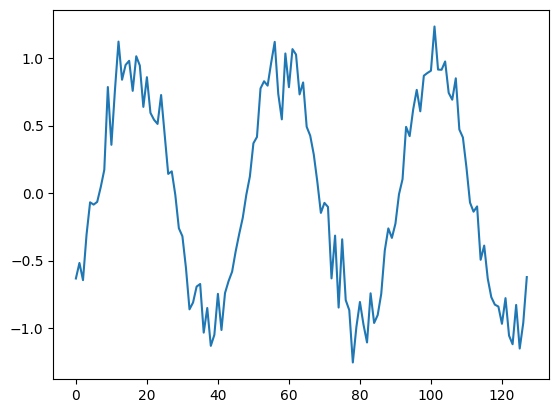

In [14]:
import numpy as np

def make_phase_wheel(
        n_classes=8,
        samples_per_class=400,
        length=128,
        freq=3.0,                 # Hz of underlying sine
        noise_std=0.15,
        seed=0):
    """
    Returns X ∈ ℝ^{N×L}, y ∈ {0,…,K-1}
      • K phase-shift classes on a unit circle
      • optional additive Gaussian noise
    """
    rng = np.random.default_rng(seed)
    t   = np.linspace(0, 1, length, endpoint=False)

    X, y = [], []
    for k in range(n_classes):
        phi = 2*np.pi * k / n_classes            # phase shift
        centre = np.sin(2*np.pi*freq*t + phi)    # prototype waveform

        # blobs: random amplitude jitter & additive noise
        amps = 1.0 + rng.normal(0, 0.05, size=samples_per_class)
        noise = rng.normal(0, noise_std, size=(samples_per_class, length))
        Xk = amps[:, None] * centre + noise

        X.append(Xk);  y.append(np.full(samples_per_class, k))

    return np.vstack(X).astype("float32"), np.concatenate(y).astype("int64")


import matplotlib.pyplot as plt

X, y = make_phase_wheel()
plt.plot(X[-1])


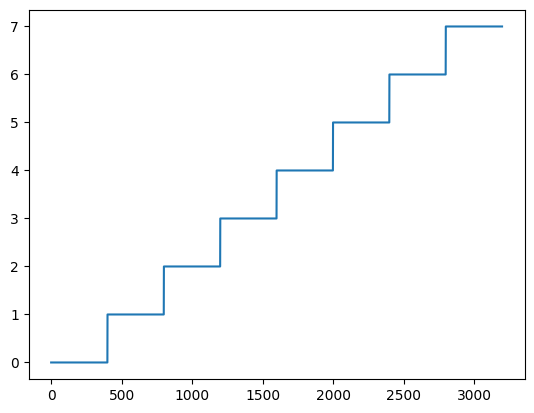

In [12]:
plt.plot(y)